In [2]:
# imports and setup

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import ElasticNet
from sklearn.model_selection import KFold, GridSearchCV, validation_curve
from sklearn.pipeline import Pipeline

from src.preprocessing import load_data, build_preprocessor

os.makedirs("plots", exist_ok=True)

In [15]:
# load data and build preprocessor
X, y, X_new = load_data()

# dropping the same columns as dne during the training
X = X.drop(columns=["C_02"])
X_new = X_new.drop(columns=["C_02"])
preprocessor = build_preprocessor(X)

### Correlation of numeric features

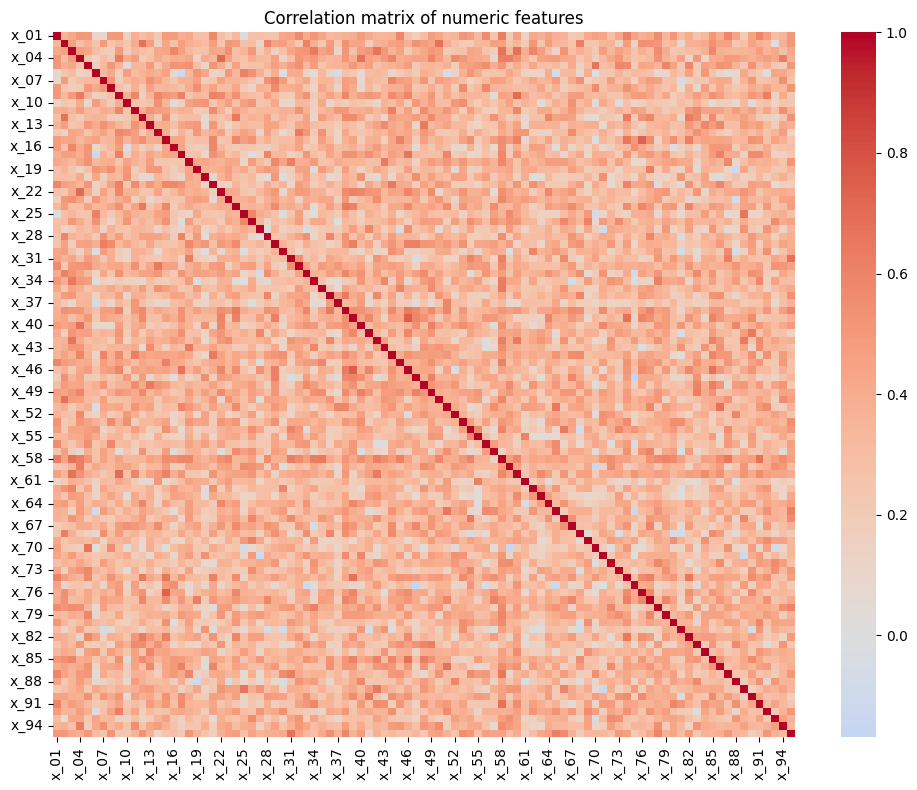

In [16]:
num_cols = [c for c in X.columns if c.startswith("x_")]
corr = X[num_cols].corr() 

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix of numeric features")
plt.savefig("plots/numeric_correlation_matrix.png", dpi=300)
plt.tight_layout()
plt.show()

### Correlation between features and  target

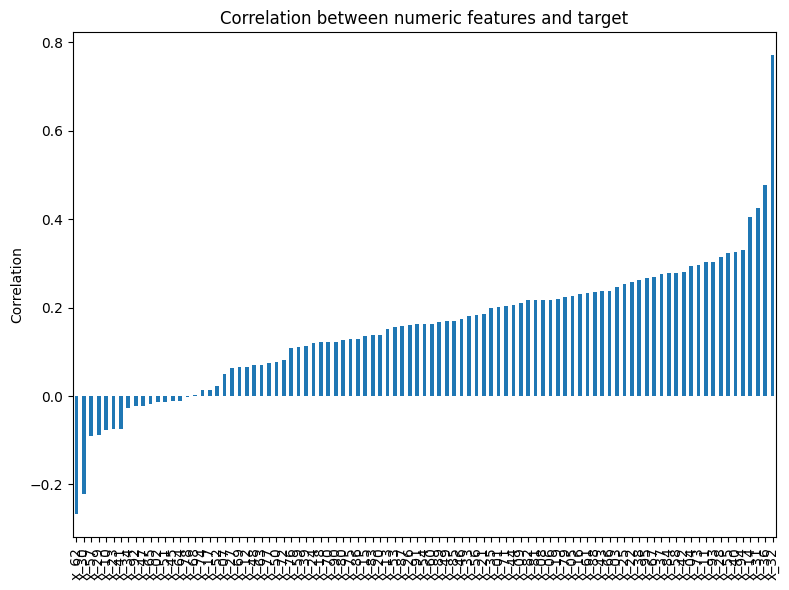

In [17]:
feature_corr = X[num_cols].corrwith(y)

plt.figure(figsize=(8,6))
feature_corr.sort_values().plot(kind="bar")
plt.title("Correlation between numeric features and target")
plt.ylabel("Correlation")
plt.tight_layout()
plt.savefig("plots/feature_target_correlation.png", dpi=300)
plt.show()

In [18]:
# defining pipeline and running GridSearchCV (same as model training) for model evaluation

model = ElasticNet(max_iter=50000, tol=1e-3, random_state=0)

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", model)
])

param_grid = {
    "model__alpha": np.logspace(-3, 2, 10),
    "model__l1_ratio": [0.1, 0.5, 0.9]
}

cv = KFold(n_splits=10, shuffle=True, random_state=0)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv
)

grid.fit(X, y)

best_rmse = -grid.best_score_
best_params = grid.best_params_
best_pipeline = grid.best_estimator_

print("Best hyperparameters:", best_params)
print("Estimated RMSE (CV):", best_rmse)

Best hyperparameters: {'model__alpha': np.float64(0.5994842503189409), 'model__l1_ratio': 0.9}
Estimated RMSE (CV): 32.98920938508818


### Validation curve from cv_results_

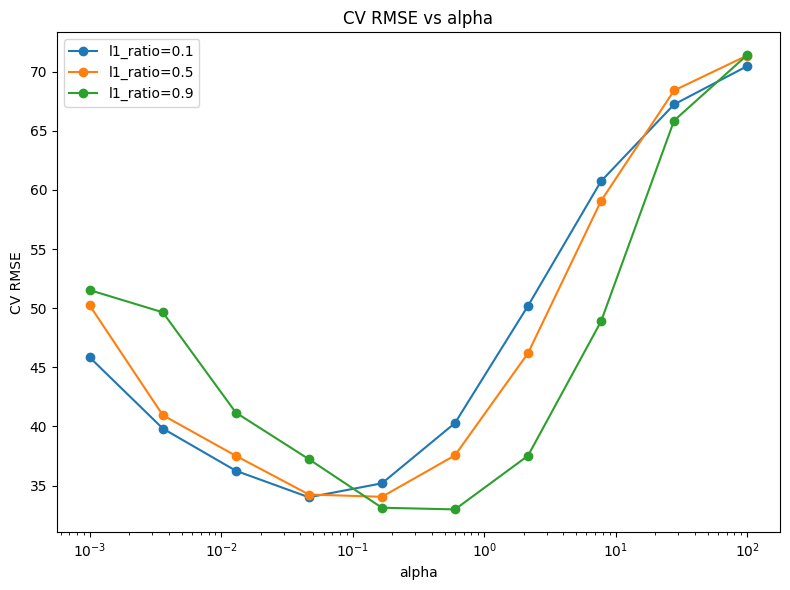

In [21]:
cv_results = pd.DataFrame(grid.cv_results_)
cv_results["alpha"] = cv_results["param_model__alpha"].astype(float)
cv_results["l1_ratio"] = cv_results["param_model__l1_ratio"].astype(float)
cv_results["rmse"] = -cv_results["mean_test_score"]

plt.figure(figsize=(8, 6))
for l1 in sorted(cv_results["l1_ratio"].unique()):
    sub = cv_results[cv_results["l1_ratio"] == l1]
    plt.plot(sub["alpha"], sub["rmse"], marker="o", label=f"l1_ratio={l1}")

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("CV RMSE")
plt.title("CV RMSE vs alpha")
plt.legend()
plt.tight_layout()
plt.savefig("plots/elasticnet_validation_curve.png", dpi=300)
plt.show()

### Regularization path (using fnal l1_ratio)

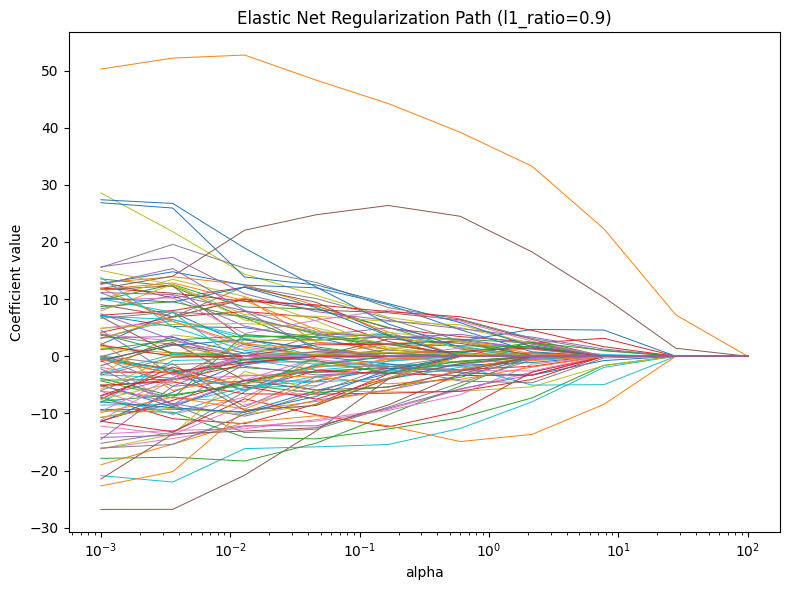

In [22]:
X_proc = preprocessor.fit_transform(X)

alphas = np.logspace(-3, 2, 10)
coefs = []
l1_ratio = best_params["model__l1_ratio"]

for a in alphas:
    m = ElasticNet(alpha=a, l1_ratio=l1_ratio, max_iter=50000, tol=1e-3, random_state=0)
    m.fit(X_proc, y)
    coefs.append(m.coef_)

coefs = np.array(coefs)

plt.figure(figsize=(8, 6))
for i in range(coefs.shape[1]):
    plt.plot(alphas, coefs[:, i], linewidth=0.7)

plt.xscale("log")
plt.xlabel("alpha")
plt.ylabel("Coefficient value")
plt.title(f"Elastic Net Regularization Path (l1_ratio={l1_ratio})")
plt.tight_layout()
plt.savefig("plots/elasticnet_path.png", dpi=300)
plt.show()

### Top coefficients of final model

Non‑zero coefficients: 72 out of 115


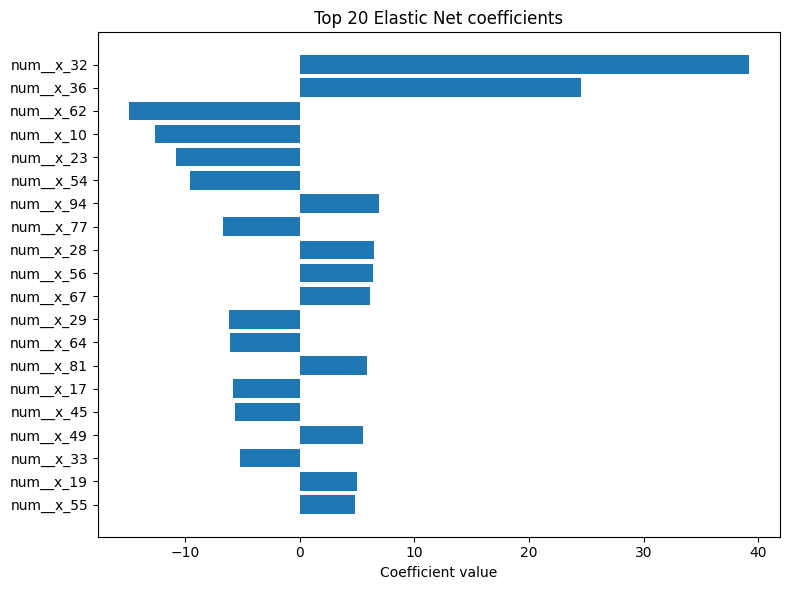

In [23]:
elasticnet_model = best_pipeline.named_steps["model"]
feature_names = best_pipeline.named_steps["preprocessor"].get_feature_names_out()
coef = elasticnet_model.coef_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coef})
coef_df["abs_coef"] = coef_df["coef"].abs()
top = coef_df.sort_values("abs_coef", ascending=False).head(20)

print("Non‑zero coefficients:", (coef != 0).sum(), "out of", len(coef))

plt.figure(figsize=(8, 6))
plt.barh(top["feature"], top["coef"])
plt.gca().invert_yaxis()
plt.xlabel("Coefficient value")
plt.title("Top 20 Elastic Net coefficients")
plt.tight_layout()
plt.savefig("plots/elasticnet_top_coefs.png", dpi=300)
plt.show()

## True vs predicted and residual plots

In [24]:
y_hat = best_pipeline.predict(X)
residuals = y - y_hat

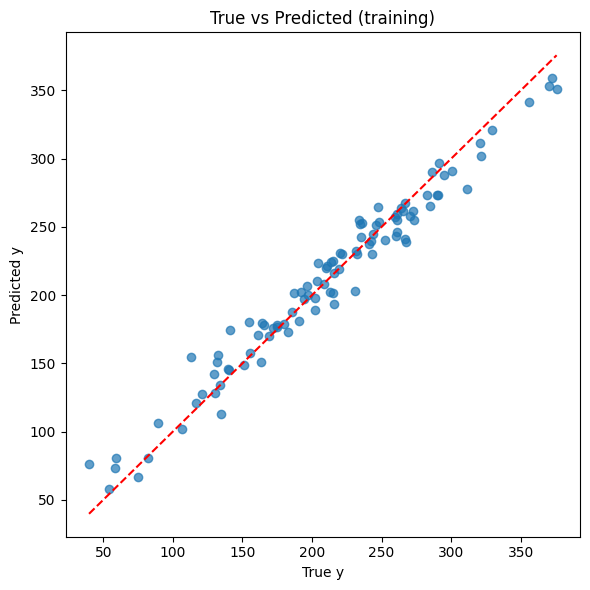

In [25]:
# true vs predicted
plt.figure(figsize=(6, 6))
plt.scatter(y, y_hat, alpha=0.7)
lims = [min(y.min(), y_hat.min()), max(y.max(), y_hat.max())]
plt.plot(lims, lims, "r--")
plt.xlabel("True y")
plt.ylabel("Predicted y")
plt.title("True vs Predicted (training)")
plt.tight_layout()
plt.savefig("plots/true_vs_predicted.png", dpi=300)
plt.show()

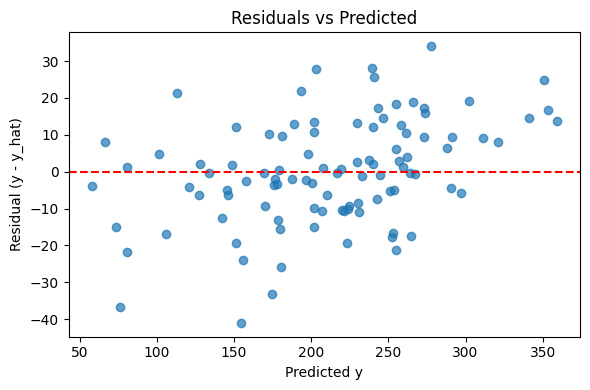

In [26]:
# residuals vs predicted
plt.figure(figsize=(6, 4))
plt.scatter(y_hat, residuals, alpha=0.7)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Predicted y")
plt.ylabel("Residual (y - y_hat)")
plt.title("Residuals vs Predicted")
plt.tight_layout()
plt.savefig("plots/residuals_vs_predicted.png", dpi=300)
plt.show()

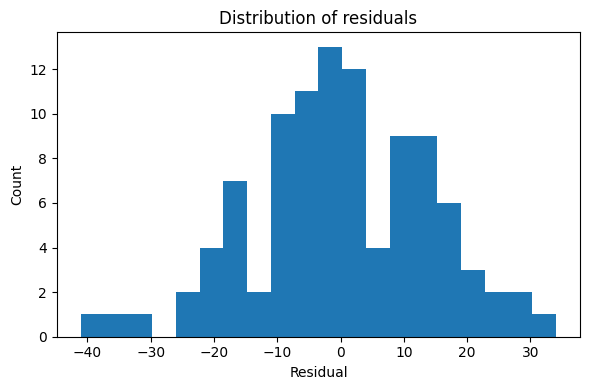

In [27]:
# residual histogram
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=20)
plt.xlabel("Residual")
plt.ylabel("Count")
plt.title("Distribution of residuals")
plt.tight_layout()
plt.savefig("plots/residual_histogram.png", dpi=300)
plt.show()

### Nested CV per outer fold

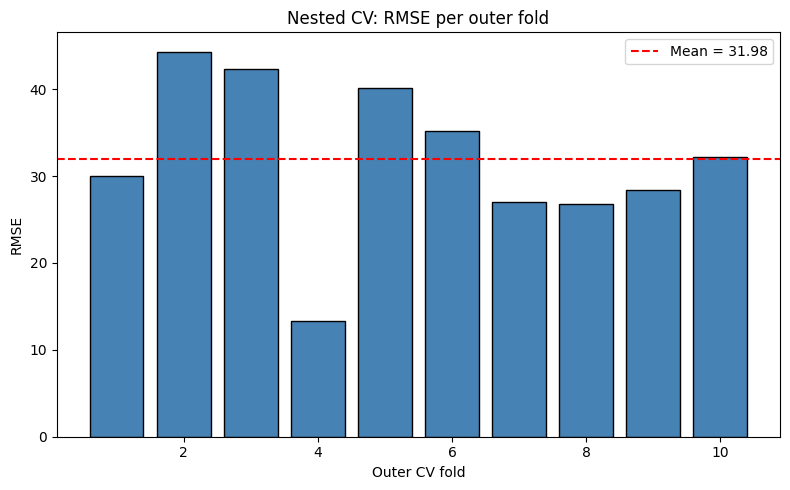

In [3]:
nested_rmse_per_fold = [30.05, 44.33, 42.29, 13.34, 40.17,
                        35.15, 27.02, 26.84, 28.38, 32.18]

plt.figure(figsize=(8, 5))
plt.bar(range(1, 11), nested_rmse_per_fold, color="steelblue", edgecolor="black")
plt.axhline(np.mean(nested_rmse_per_fold), color="red", linestyle="--",
            label=f"Mean = {np.mean(nested_rmse_per_fold):.2f}")
plt.xlabel("Outer CV fold")
plt.ylabel("RMSE")
plt.title("Nested CV: RMSE per outer fold")
plt.legend()
plt.tight_layout()
plt.savefig("plots/nested_cv_folds.png", dpi=300)
plt.show()